In [1]:
from itertools import product as iproduct

for outcome in iproduct(range(4), repeat=4):
    # prodotto tensoriale M(a1) ⊗ M(a2) ⊗ ... ⊗ M(aN)
    print (outcome, outcome[0], type(outcome))

(0, 0, 0, 0) 0 <class 'tuple'>
(0, 0, 0, 1) 0 <class 'tuple'>
(0, 0, 0, 2) 0 <class 'tuple'>
(0, 0, 0, 3) 0 <class 'tuple'>
(0, 0, 1, 0) 0 <class 'tuple'>
(0, 0, 1, 1) 0 <class 'tuple'>
(0, 0, 1, 2) 0 <class 'tuple'>
(0, 0, 1, 3) 0 <class 'tuple'>
(0, 0, 2, 0) 0 <class 'tuple'>
(0, 0, 2, 1) 0 <class 'tuple'>
(0, 0, 2, 2) 0 <class 'tuple'>
(0, 0, 2, 3) 0 <class 'tuple'>
(0, 0, 3, 0) 0 <class 'tuple'>
(0, 0, 3, 1) 0 <class 'tuple'>
(0, 0, 3, 2) 0 <class 'tuple'>
(0, 0, 3, 3) 0 <class 'tuple'>
(0, 1, 0, 0) 0 <class 'tuple'>
(0, 1, 0, 1) 0 <class 'tuple'>
(0, 1, 0, 2) 0 <class 'tuple'>
(0, 1, 0, 3) 0 <class 'tuple'>
(0, 1, 1, 0) 0 <class 'tuple'>
(0, 1, 1, 1) 0 <class 'tuple'>
(0, 1, 1, 2) 0 <class 'tuple'>
(0, 1, 1, 3) 0 <class 'tuple'>
(0, 1, 2, 0) 0 <class 'tuple'>
(0, 1, 2, 1) 0 <class 'tuple'>
(0, 1, 2, 2) 0 <class 'tuple'>
(0, 1, 2, 3) 0 <class 'tuple'>
(0, 1, 3, 0) 0 <class 'tuple'>
(0, 1, 3, 1) 0 <class 'tuple'>
(0, 1, 3, 2) 0 <class 'tuple'>
(0, 1, 3, 3) 0 <class 'tuple'>
(0, 2, 0

In [3]:
from povm_sampling import *
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix

def create_ghz_state(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(0)
    for i in range(1, n_qubits):
        qc.cx(0, i)
    # qc.measure_all()
    return qc
qc = create_ghz_state(5)
rho = DensityMatrix(qc)
print(rho.data)
# plot_state_city(rho)

prob = povm_probability(rho.data, 5)
print(prob)

[[0.5+0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0.5+0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 ...
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0. +0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0. +0.j]
 [0.5+0.j 0. +0.j 0. +0.j ... 0. +0.j 0. +0.j 0.5+0.j]]
{(0, 0, 0, 0, 0): 0.015625, (0, 0, 0, 0, 1): 0.005208333333333334, (0, 0, 0, 0, 2): 0.005208333333333334, (0, 0, 0, 0, 3): 0.005208333333333334, (0, 0, 0, 1, 0): 0.005208333333333334, (0, 0, 0, 1, 1): 0.0017361111111111114, (0, 0, 0, 1, 2): 0.0017361111111111114, (0, 0, 0, 1, 3): 0.0017361111111111114, (0, 0, 0, 2, 0): 0.005208333333333334, (0, 0, 0, 2, 1): 0.0017361111111111114, (0, 0, 0, 2, 2): 0.0017361111111111114, (0, 0, 0, 2, 3): 0.0017361111111111114, (0, 0, 0, 3, 0): 0.005208333333333334, (0, 0, 0, 3, 1): 0.0017361111111111114, (0, 0, 0, 3, 2): 0.0017361111111111114, (0, 0, 0, 3, 3): 0.0017361111111111114, (0, 0, 1, 0, 0): 0.005208333333333334, (0,

In [11]:
samples = sample_povm(prob, 1000000)
p_emp = samples_to_empirical_dist(samples, 5)
print(p_emp)

{(0, 0, 0, 0, 0): 0.015625, (0, 0, 0, 0, 1): 0.005133, (0, 0, 0, 0, 2): 0.005133, (0, 0, 0, 0, 3): 0.005251, (0, 0, 0, 1, 0): 0.005272, (0, 0, 0, 1, 1): 0.001674, (0, 0, 0, 1, 2): 0.001722, (0, 0, 0, 1, 3): 0.001698, (0, 0, 0, 2, 0): 0.005186, (0, 0, 0, 2, 1): 0.001745, (0, 0, 0, 2, 2): 0.001666, (0, 0, 0, 2, 3): 0.001717, (0, 0, 0, 3, 0): 0.00518, (0, 0, 0, 3, 1): 0.001698, (0, 0, 0, 3, 2): 0.001737, (0, 0, 0, 3, 3): 0.001648, (0, 0, 1, 0, 0): 0.005327, (0, 0, 1, 0, 1): 0.001731, (0, 0, 1, 0, 2): 0.001779, (0, 0, 1, 0, 3): 0.001684, (0, 0, 1, 1, 0): 0.001738, (0, 0, 1, 1, 1): 0.000586, (0, 0, 1, 1, 2): 0.000581, (0, 0, 1, 1, 3): 0.000599, (0, 0, 1, 2, 0): 0.001732, (0, 0, 1, 2, 1): 0.00057, (0, 0, 1, 2, 2): 0.000616, (0, 0, 1, 2, 3): 0.000623, (0, 0, 1, 3, 0): 0.001766, (0, 0, 1, 3, 1): 0.000543, (0, 0, 1, 3, 2): 0.000608, (0, 0, 1, 3, 3): 0.000574, (0, 0, 2, 0, 0): 0.005266, (0, 0, 2, 0, 1): 0.001726, (0, 0, 2, 0, 2): 0.001744, (0, 0, 2, 0, 3): 0.001788, (0, 0, 2, 1, 0): 0.001708, (0

# test mle

In [2]:
import sys
sys.path.append('../src')

In [4]:
# test of mle
from mle import *
from utils import *
from povm_sampling import *
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import DensityMatrix
from qiskit.visualization import plot_state_city, plot_state_hinton, plot_state_qsphere


┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

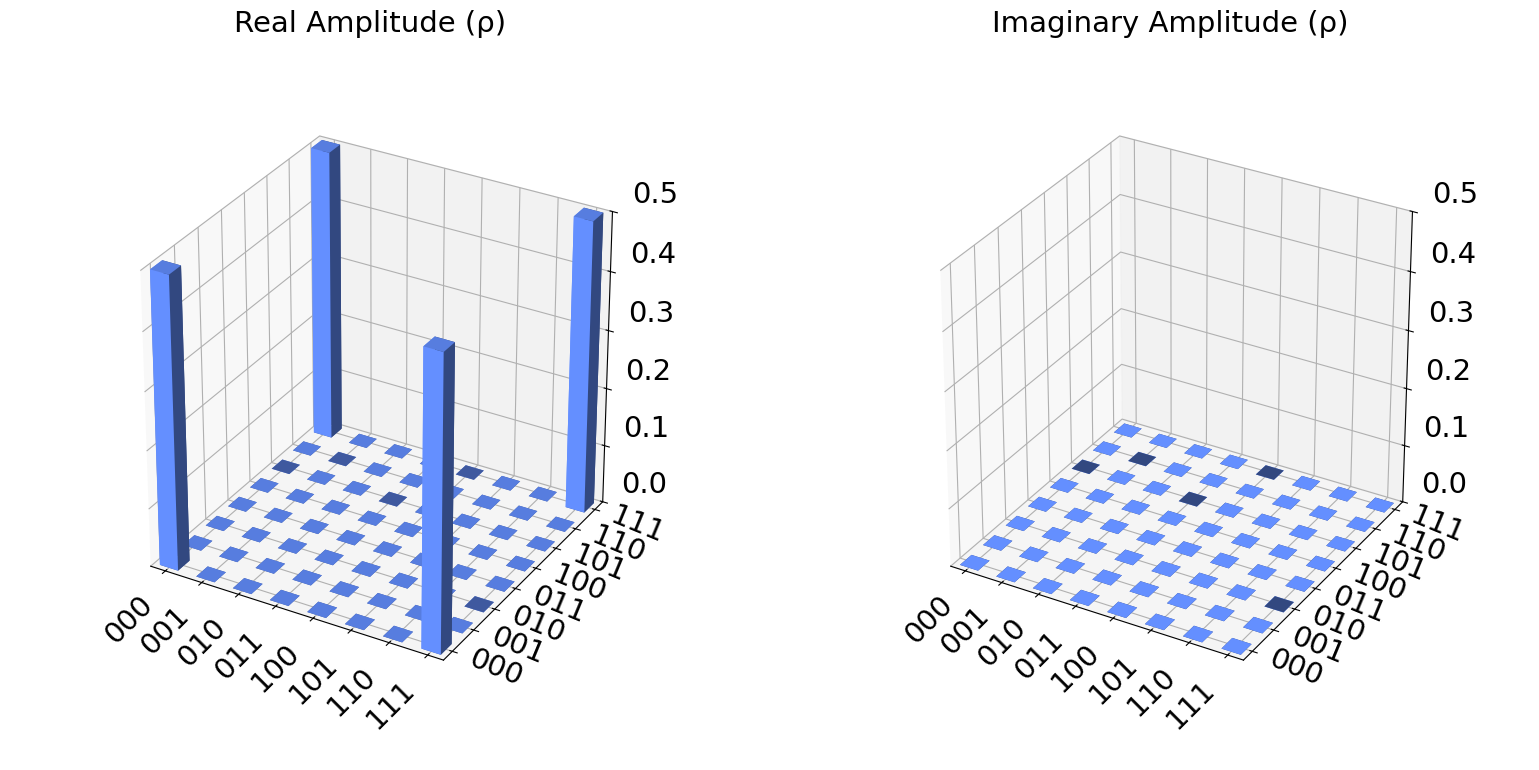

In [5]:
# state simulation
def create_ghz_state(n_qubits):
    qc = QuantumCircuit(n_qubits)
    qc.h(0)
    for i in range(1, n_qubits):
        qc.cx(0, i)
    return qc
N = 3
qc = create_ghz_state(N)
display(qc.draw())

rho = DensityMatrix(qc)
fig = plot_state_city(rho)
display(fig)

In [6]:
# create data
p_exact = povm_probability(rho.data, N)
samples = sample_povm(p_exact, 1000)


In [7]:
# minuit
dim = 2**N
init_rho = np.eye(dim, dtype=complex) / dim   # max mixed state
p0 = rho_to_params(init_rho, N)

print(f"Parametri Cholesky: {count_params(N)}  (= (2^N)^2 = {dim**2})")


nll = make_nll(samples, N)

# Minuit
m = Minuit(nll, *p0)
# iminuit built-in to use custom likelihood cost func --> for error estimation m.minos
m.errordef = Minuit.LIKELIHOOD   # = 0.5    
m.print_level = 0

m.migrad()                  
if not m.valid:
    print('not valid!')
    # second try
    m.migrad()              


Parametri Cholesky: 64  (= (2^N)^2 = 64)


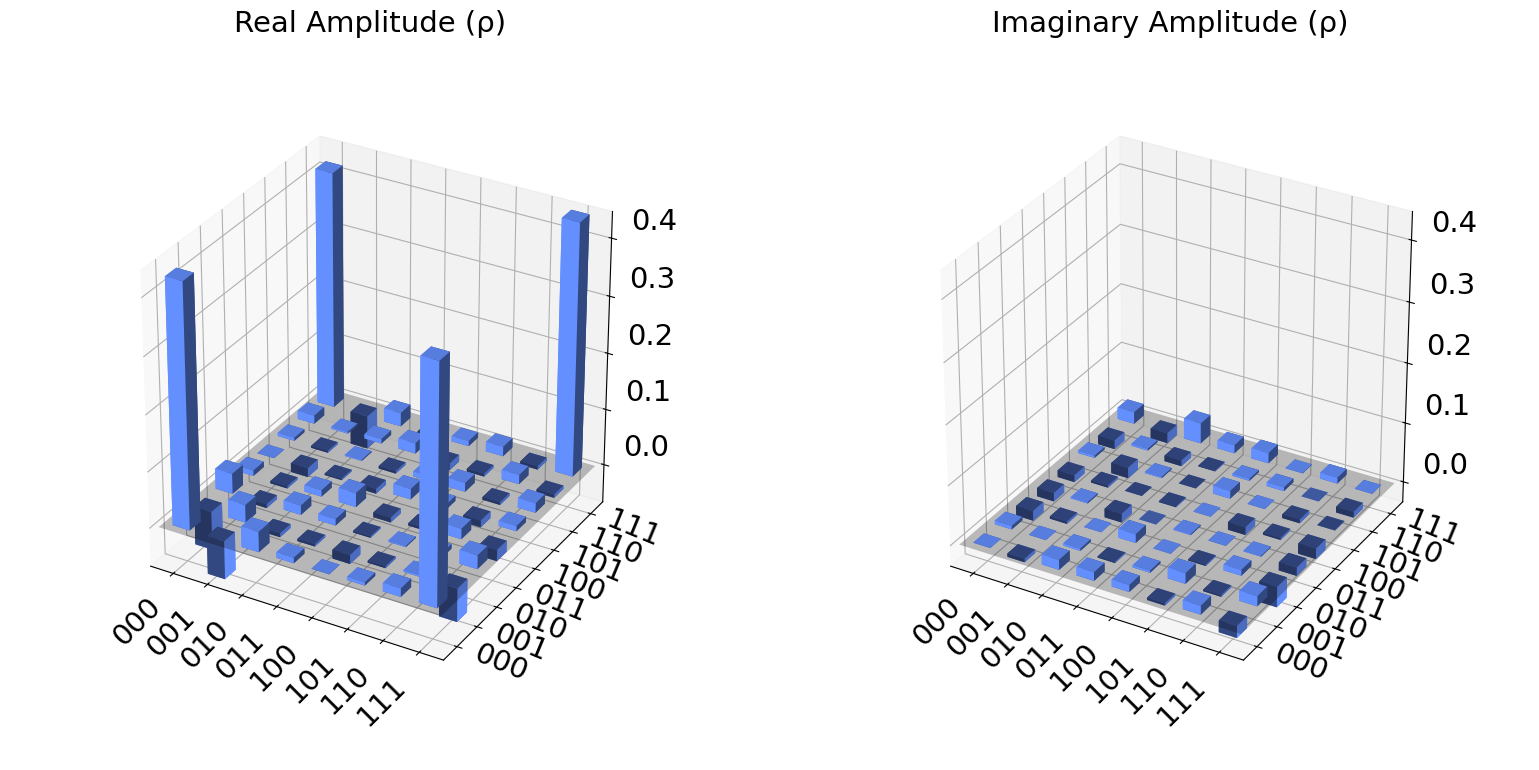

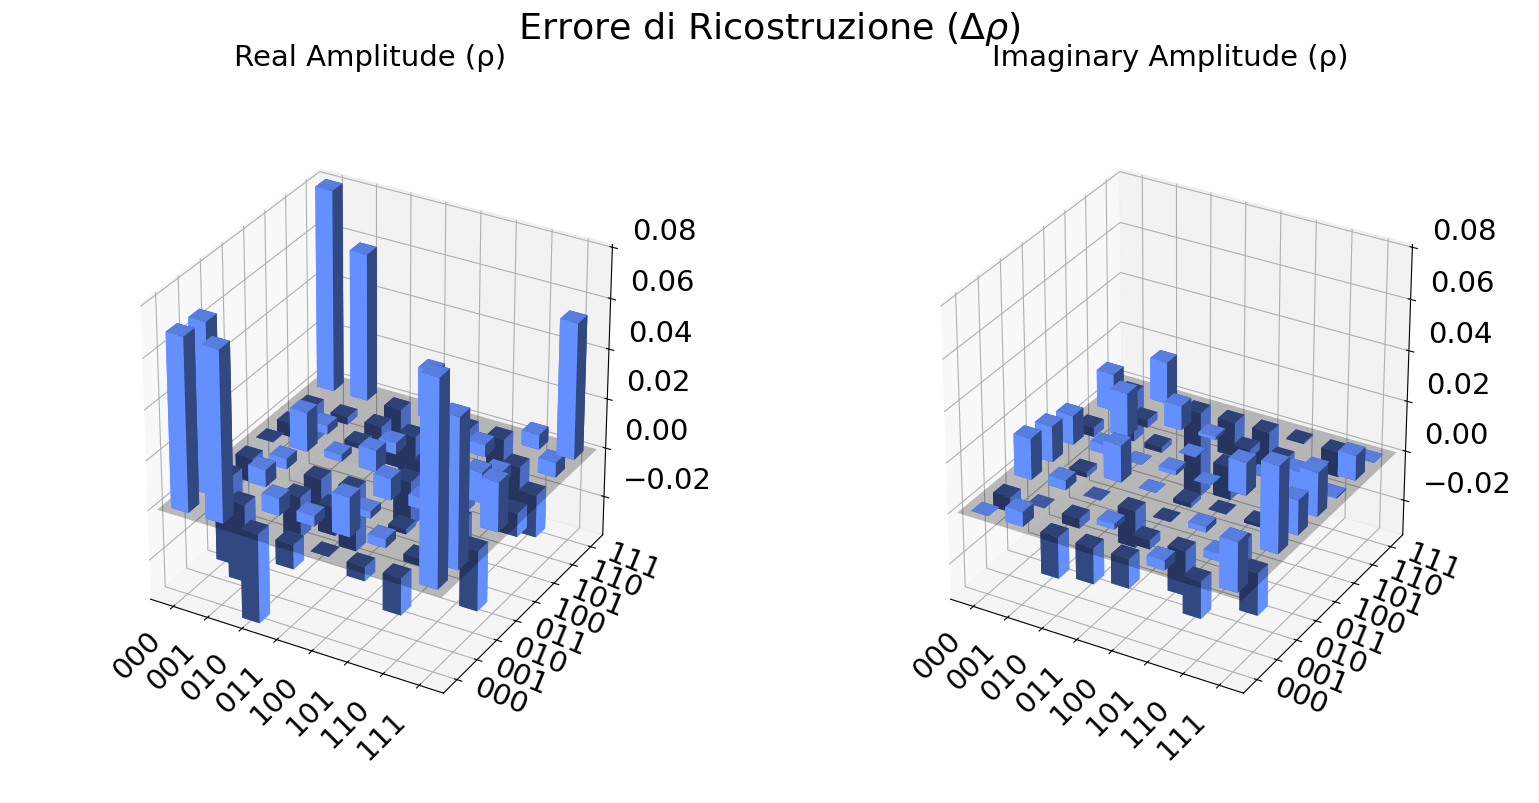

In [8]:
rho_est = params_to_rho(np.array(m.values), N)
fig = plot_state_city(rho_est)
display(fig)

# Calcoli la differenza tra le due matrici
rho_diff = rho - rho_est

# Fai il plot: i grattacieli alti indicheranno dove la tua MLE ha sbagliato di più, 
# mentre se le matrici sono identiche vedrai un grafico completamente piatto a zero.
fig = plot_state_city(rho_diff, title="Errore di Ricostruzione ($\\Delta\\rho$)")
display(fig)

In [9]:
print(f"Convergenza Minuit:  {m.valid}")
print(f"Tr(rho_mle):         {np.real(np.trace(rho_est)):.8f}")
print(f"Hermitiana:          {np.allclose(rho_est, rho_est.conj().T)}")
eigs = np.linalg.eigvalsh(rho_est)
print(f"Autovalori minimi:   {min(eigs):.2e}  (deve essere >= 0)")

Convergenza Minuit:  True
Tr(rho_mle):         1.00000000
Hermitiana:          True
Autovalori minimi:   2.80e-11  (deve essere >= 0)


In [10]:
# fidelity --> they are from utils.py
fq = quantum_fidelity(rho, rho_est)
print(f"Fidelity quantistica F_q = {fq:.6f}")

# fidelity classica per confronto
p_mle = samples_to_empirical_dist(samples, N)
fc    = classical_fidelity(p_exact, p_mle)
print(f"Fidelity classica   F_c  = {fc:.6f}")

Fidelity quantistica F_q = 0.857054
Fidelity classica   F_c  = 0.988477
